In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

#Creación

In [2]:
np.random.seed(42)

df_original = pd.read_csv('/content/dataset_full.csv')

df_original = df_original.drop_duplicates()


# Dividir en entrenamiento y prueba
df, df_test = train_test_split(df_original, test_size=0.2, random_state=42)

# Asegúrate de que df_train y df_test estén divididos correctamente
print("Entrenamiento:", df.shape)
print("Prueba:", df_test.shape)

Entrenamiento: (69767, 112)
Prueba: (17442, 112)


In [3]:
df_test.value_counts('phishing')

,count
phishing,
0,11364
1,6078


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necesario para la gráfica 3D

def pca_and_plot(X, y, figura_x=10, figura_y=10):
    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA con 2 componentes (en lugar de 3)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # Crear DataFrame con componentes principales
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'PCA {i+1}' for i in range(2)],
                          index=X.index)


    # Gráfico 2D
    fig, ax = plt.subplots(figsize=(figura_x, figura_y))
    ax.scatter(pca_df['PCA 1'], pca_df['PCA 2'],
               c='#1f77b4', label='Datos normales')

    ax.set_title('PCA 2D - Reducción de Dimensionalidad con Outliers')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend(loc='upper left')

    plt.grid(True)

    return fig, pca_df


In [5]:
def pca_outliers_plot(X, outliers, figura_x=10, figura_y=8):
    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA con 2 componentes (en lugar de 3)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # Crear DataFrame con componentes principales
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'PCA {i+1}' for i in range(2)],
                          index=X.index)

    # Asegurarse de alinear los índices
    pca_df = pd.concat([pca_df, outliers], axis=1)

    # Separar normales y outliers
    normales = pca_df[pca_df['outlier'] == False]
    outliers = pca_df[pca_df['outlier'] == True]

    # Gráfico 2D
    fig, ax = plt.subplots(figsize=(figura_x, figura_y))
    ax.scatter(normales['PCA 1'], normales['PCA 2'],
               c='#1f77b4', label='Datos normales')

    ax.scatter(outliers['PCA 1'], outliers['PCA 2'],
               c='#ff7f0e', marker='x', label='Outliers')

    ax.set_title('PCA 2D - Reducción de Dimensionalidad con Outliers')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend(loc='upper left')

    plt.grid(True)

    return fig, pca_df


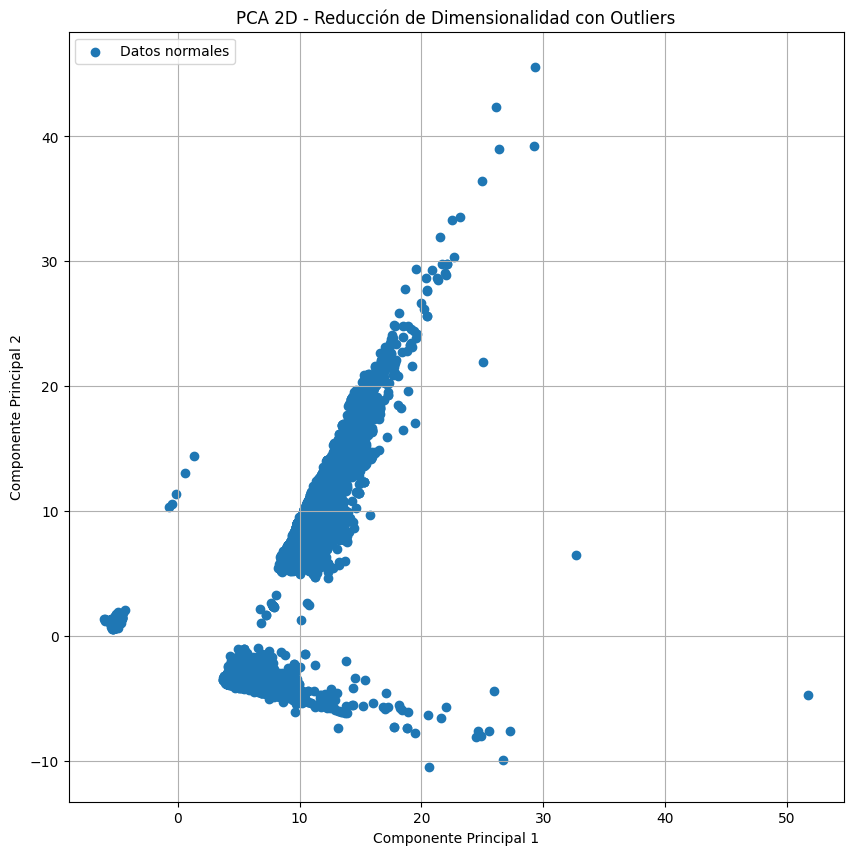

In [6]:
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df.drop(columns=['phishing']), df['phishing'])

# Mostrar la figura
plt.show()

#Detección

In [7]:
from sklearn.neighbors import LocalOutlierFactor


def isolation_forest(df):
  X = df.drop(columns=['phishing'])
  y = df['phishing']

  n_neighbors_values = [50]  # Valores típicos para LOF
  metric_values = ['chebyshev']  # Distancias posibles
  contamination_values = [0.2]  # Fracción esperada de outliers

  # Generar todas las combinaciones posibles
  combinaciones = itertools.product(n_neighbors_values, metric_values, contamination_values)


  # Realizar el grid search
  for n_neighbors, metric, contamination in combinaciones:
      # Aplicar LOF
      lof = LocalOutlierFactor(n_neighbors=n_neighbors,
                              metric=metric,
                              contamination=contamination,
                              novelty=False)  # novelty=False para detección de outliers

      # Predecir outliers (1 para inliers, -1 para outliers)
      lof_preds = lof.fit_predict(X)

      # Convertir a formato binario (0=inlier, 1=outlier)
      outliers = lof_preds == -1


  return pd.DataFrame(outliers, columns=['outlier'])


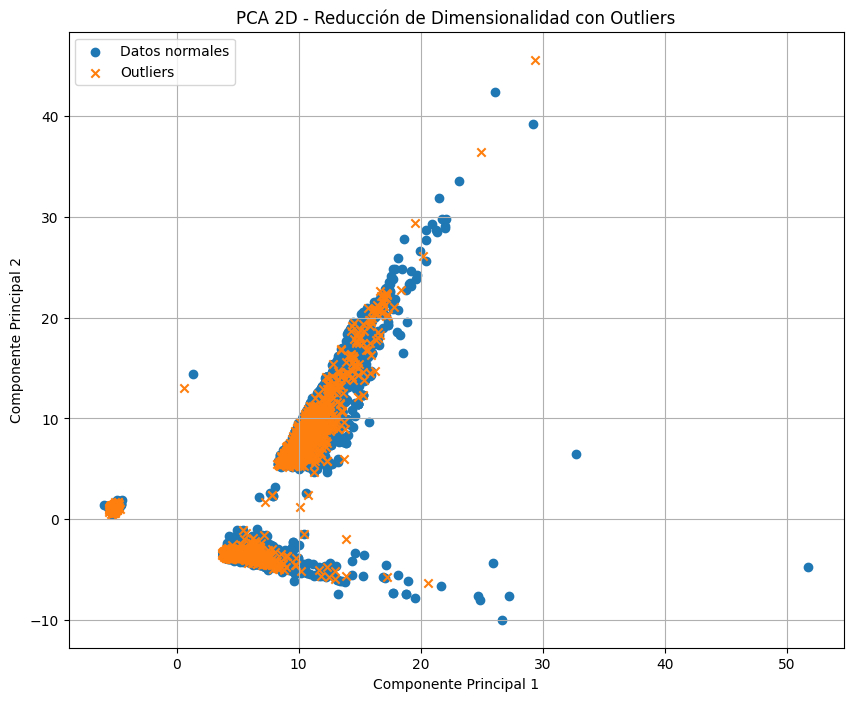

In [8]:
import matplotlib.pyplot as plt

model = 'Local Outlier Factor'
outliers = isolation_forest(df)
fig, pca = pca_outliers_plot(df.drop(columns=['phishing']), outliers)

plt.show()

In [9]:
outliers.value_counts()

,count
outlier,
False,55820
True,13947


#Tratamiento

In [10]:
result = outliers.copy()

##Dejar los outliers

In [11]:
df_completo = df.copy()
df_completo = df_completo.drop_duplicates()

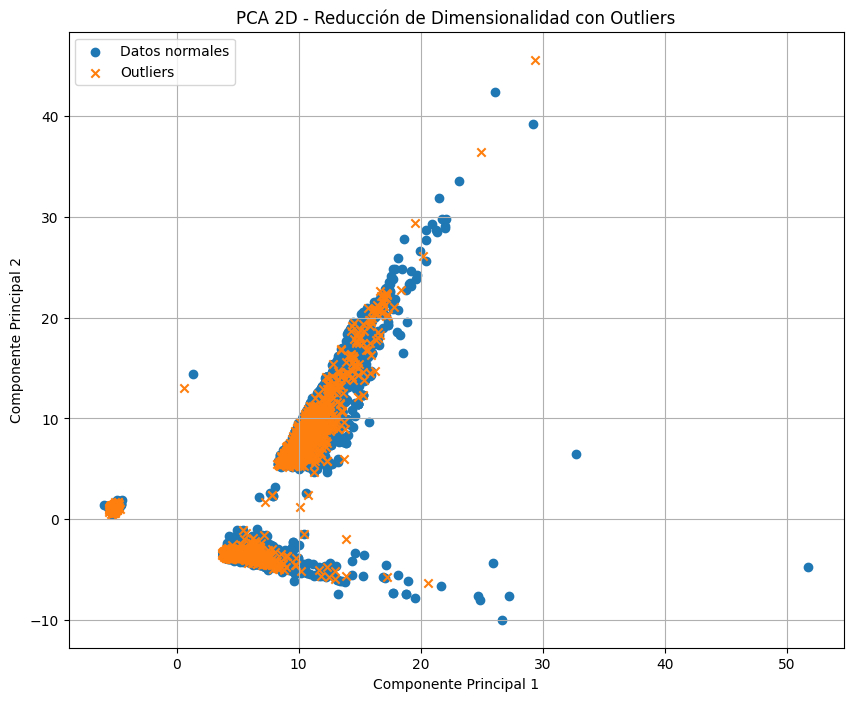

In [12]:
outliers = isolation_forest(df_completo)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_outliers_plot(df_completo.drop(columns=['phishing']), outliers)

plt.show()

##Eliminar los outliers

In [13]:
df_eliminados = df[result.set_index(df.index)['outlier']==False].copy()
df_eliminados = df_eliminados.drop_duplicates()

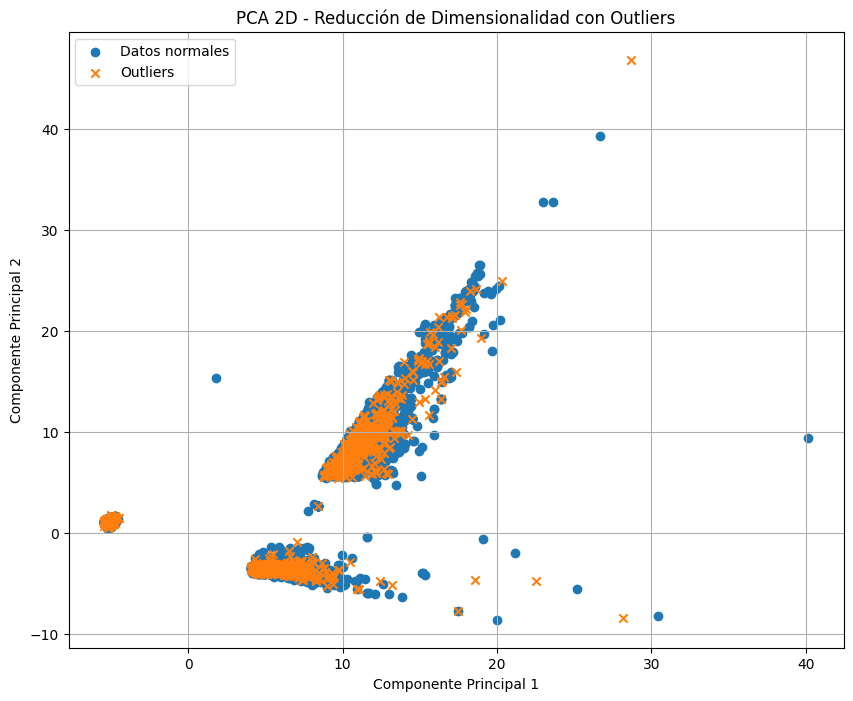

In [14]:
outliers = isolation_forest(df_eliminados)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_outliers_plot(df_eliminados.drop(columns=['phishing']), outliers)

plt.show()

##Cambiar por la media

In [15]:
# Calcular la mediana de cada columna (solo inliers)
result = result.set_index(df.index)['outlier']==False

X_mean_aux = df.drop(columns=['phishing'])
median_values = np.median(X_mean_aux[~result], axis=0)  # ~outlier_mask = inliers

X_imputed = df.drop(columns=['phishing']).copy()
# Reemplazar outliers con la mediana
X_imputed[result] = median_values
df_imputed = pd.DataFrame(X_imputed, columns=X_mean_aux.columns)
df_imputed['phishing'] = df['phishing'].values  # Asegurar alineación por índice
df_imputed = df_imputed.drop_duplicates()

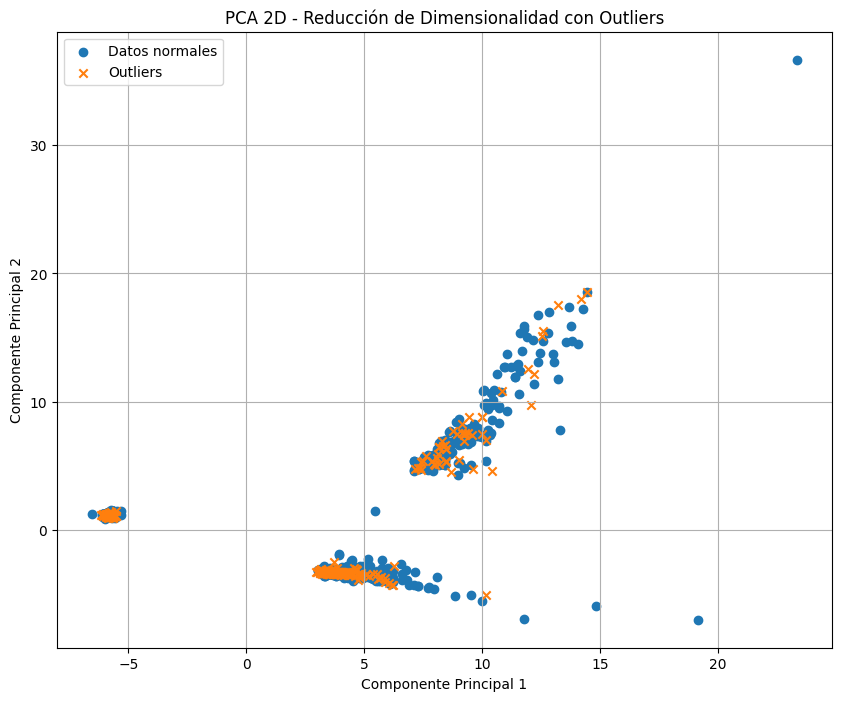

In [16]:
outliers = isolation_forest(df_imputed)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_outliers_plot(df_imputed.drop(columns=['phishing']), outliers)

plt.show()

##Winsorización

In [17]:
import pandas as pd
import numpy as np

lower_pct = 0.05
upper_pct = 0.95

X_win_aux = df.drop(columns=['phishing'])
winsorized_columns = {}

# Usar diccionario primero y luego construir el DataFrame de golpe
for col in X_win_aux.columns:
    lower_bound = X_win_aux[col].quantile(lower_pct)
    upper_bound = X_win_aux[col].quantile(upper_pct)

    # Clip manual con np.where para evitar el FutureWarning
    clipped = np.where(X_win_aux[col] < lower_bound, lower_bound,
              np.where(X_win_aux[col] > upper_bound, upper_bound, X_win_aux[col]))

    # Reconstruir la Serie conservando el índice y tipo original
    s = pd.Series(clipped, index=X_win_aux.index)

    # Cast explícito según el tipo original
    if pd.api.types.is_integer_dtype(X_win_aux[col]):
        s = s.round().astype(X_win_aux[col].dtype)
    elif pd.api.types.is_float_dtype(X_win_aux[col]):
        s = s.astype(X_win_aux[col].dtype)

    winsorized_columns[col] = s

# Crear DataFrame de una sola vez (evita fragmentación)
X_winsorized = pd.DataFrame(winsorized_columns)

# Combinar con variable objetivo
df_winsorized = pd.concat([X_winsorized, df[['phishing']]], axis=1)



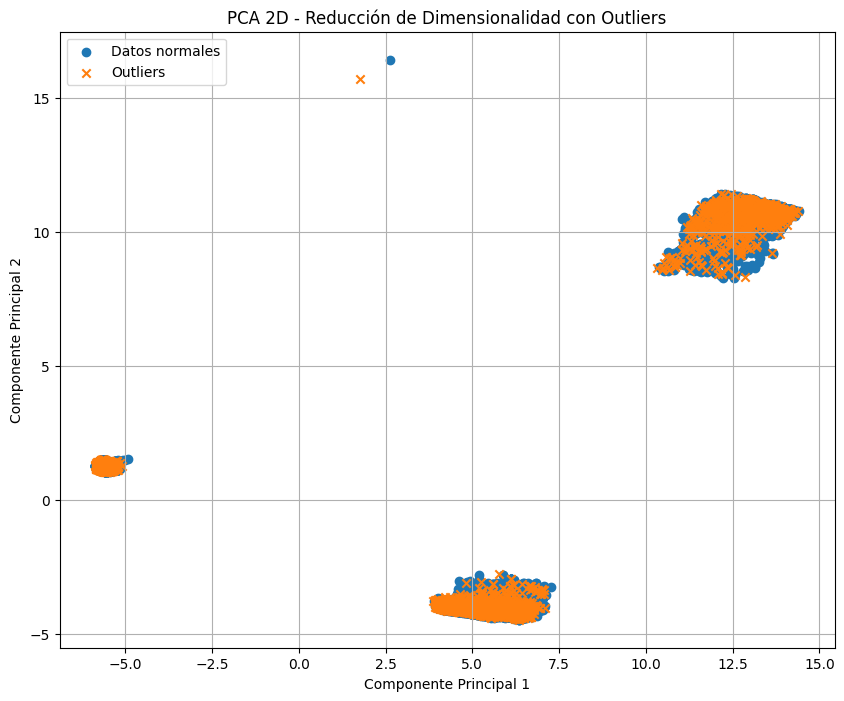

In [18]:
outliers = isolation_forest(df_winsorized)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_outliers_plot(df_winsorized.drop(columns=['phishing']), outliers)

plt.show()

#Predicción

In [19]:
from sklearn.ensemble import RandomForestClassifier  # Para clasificación
# from sklearn.ensemble import RandomForestRegressor  # Para regresión

def predict(df_train, df_test):
  X_train = df_train.drop(columns=['phishing'])
  y_train = df_train['phishing']

  X_test = df_test.drop(columns=['phishing'])
  y_test = df_test['phishing']

  # Definir el clasificador
  rf = RandomForestClassifier(random_state=42)

  # Definir los hiperparámetros que se van a optimizar, incluyendo n_estimators
  param_grid = {
      'n_estimators': [50, 100],  # Número de árboles en el bosque
      'max_depth': [None, 10],  # Profundidad máxima de los árboles
      'min_samples_split': [2, 8],  # Mínimo número de muestras necesarias para dividir un nodo
  }

  # Realizar la búsqueda de hiperparámetros
  grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=3)

  # Ajustar el modelo con la búsqueda en la cuadrícula
  grid_search.fit(X_train, y_train)

  # Mostrar los mejores parámetros encontrados
  print("Mejores parámetros: ", grid_search.best_params_)

  # Obtener el mejor modelo encontrado por GridSearchCV
  best_rf = grid_search.best_estimator_

  # Hacer predicciones sobre el conjunto de prueba (X_test)
  y_pred = best_rf.predict(X_test)

  # Evaluar la precisión del modelo
  accuracy = accuracy_score(y_test, y_pred)
  print(f'Precisión del modelo: {accuracy}')

  # Ver las predicciones
  print('Predicciones: ', y_pred)
  return y_test, y_pred


In [20]:
def plot_confusion_matrix(y_test, y_pred):
  # Calcular la matriz
  cm = confusion_matrix(y_test, y_pred)
  # Si sabes los nombres de las clases, ponlos aquí:
  class_names = ['Falso', 'Verdadero']  # cambia según tus etiquetas

  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.xlabel('Predicción')
  plt.ylabel('Real')
  plt.title('Matriz de Confusión')
  plt.tight_layout()
  plt.show()

  print(classification_report(y_test, y_pred, target_names=class_names))

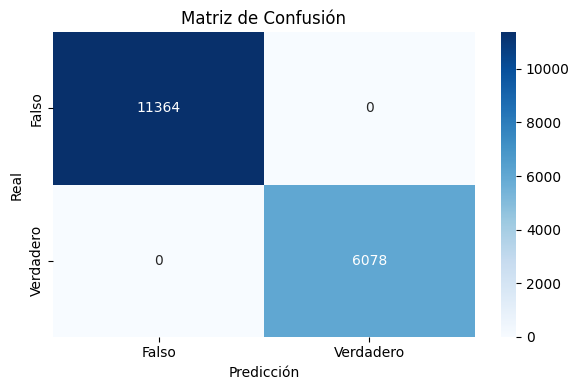

              precision    recall  f1-score   support

       Falso       1.00      1.00      1.00     11364
   Verdadero       1.00      1.00      1.00      6078

    accuracy                           1.00     17442
   macro avg       1.00      1.00      1.00     17442
weighted avg       1.00      1.00      1.00     17442



In [21]:
plot_confusion_matrix(df_test['phishing'], df_test['phishing'])

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Precisión del modelo: 0.954248366013072
Predicciones:  [1 0 1 ... 1 0 1]


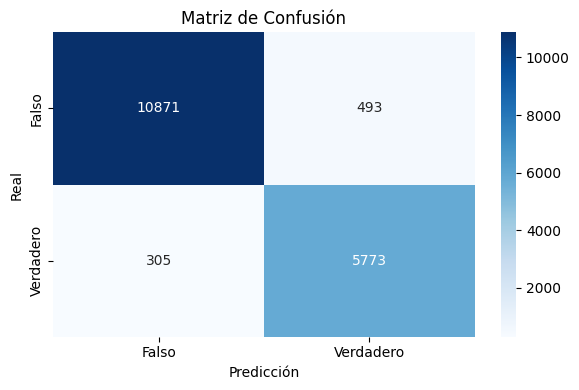

              precision    recall  f1-score   support

       Falso       0.97      0.96      0.96     11364
   Verdadero       0.92      0.95      0.94      6078

    accuracy                           0.95     17442
   macro avg       0.95      0.95      0.95     17442
weighted avg       0.95      0.95      0.95     17442



In [22]:
y_test, y_pred = predict(df_imputed, df_test)
plot_confusion_matrix(y_test, y_pred)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Precisión del modelo: 0.968925581928678
Predicciones:  [1 0 1 ... 1 0 1]


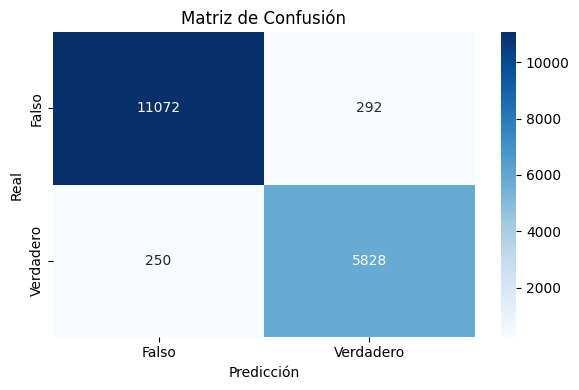

              precision    recall  f1-score   support

       Falso       0.98      0.97      0.98     11364
   Verdadero       0.95      0.96      0.96      6078

    accuracy                           0.97     17442
   macro avg       0.97      0.97      0.97     17442
weighted avg       0.97      0.97      0.97     17442



In [23]:
y_test, y_pred = predict(df_winsorized, df_test)
plot_confusion_matrix(y_test, y_pred)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Precisión del modelo: 0.9695562435500515
Predicciones:  [1 0 1 ... 1 0 1]


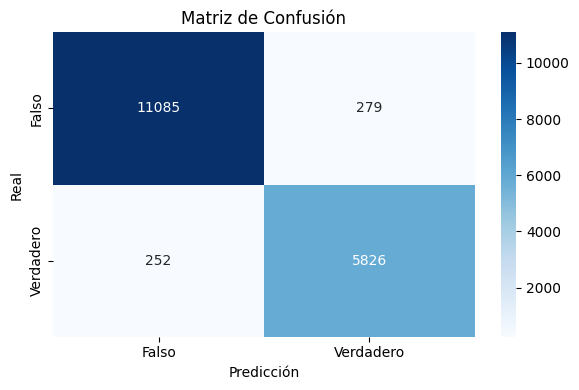

              precision    recall  f1-score   support

       Falso       0.98      0.98      0.98     11364
   Verdadero       0.95      0.96      0.96      6078

    accuracy                           0.97     17442
   macro avg       0.97      0.97      0.97     17442
weighted avg       0.97      0.97      0.97     17442



In [24]:
y_test, y_pred = predict(df_completo, df_test)
plot_confusion_matrix(y_test, y_pred)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Precisión del modelo: 0.9661162710698314
Predicciones:  [1 0 1 ... 1 0 1]


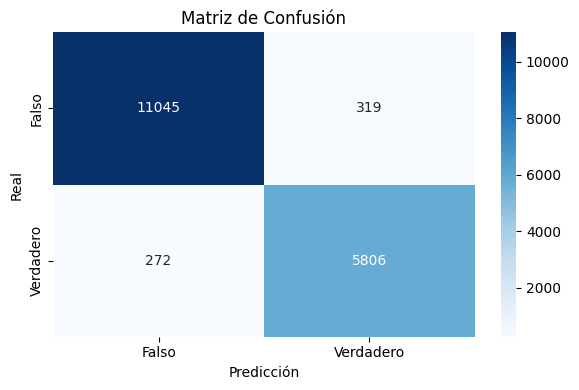

              precision    recall  f1-score   support

       Falso       0.98      0.97      0.97     11364
   Verdadero       0.95      0.96      0.95      6078

    accuracy                           0.97     17442
   macro avg       0.96      0.96      0.96     17442
weighted avg       0.97      0.97      0.97     17442



In [25]:
y_test, y_pred = predict(df_eliminados, df_test)
plot_confusion_matrix(y_test, y_pred)